In [51]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import itertools
import seaborn as sns
import scipy.stats as stats

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [52]:
df = pd.read_excel('2.1阳光信息.xlsx')
df = df.drop('flag',axis=1)
df.columns

Index(['Y', '路障', '撑杆', '铁桶', '读报', '铁门', '橄榄', '舞王', '潜水', '冰车', '海豚', '小丑',
       '气球', '矿工', '跳跳', '蹦极', '扶梯', '投篮', '白眼', '红眼', '权重和'],
      dtype='object')

In [53]:
cols =  df.columns.values
cols = cols[~np.isin(cols, ['Y'])]
df[cols] = df[cols].replace(0,-1)
df['密度'] = -1
df.loc[df['权重和']<12000,'密度'] = 1
df = df.drop('权重和',axis=1)

In [54]:
# handle
# df['Y'] -= 

In [55]:
def OLS_factor_DIY_model(df,main_factors,cross_factors,intercept = True):
    # df['Y'] = -df['Y']
    
    formula = 'Y ~ '
    df_cols = df.columns[~np.isin(df.columns, ['Y'])]

    formula_terms = []
            
    for fact in main_factors:
        formula_terms.append(fact)
    
    for fact in cross_factors:
        formula_terms.append(fact)
            
    formula = formula  + '+'.join(formula_terms)
    if not intercept:
        formula = formula + '+0'
    print(formula)

    model = ols(formula, data=df).fit()

    coefs = model.params
    # 构建带系数的表达式
    coefs = model.params
    formula_parts = []
    if 'Intercept' in coefs:
        formula_parts.append(f"{coefs['Intercept']:.4f}")  # 保留4位小数

    for var, coef in coefs.items():
        if var != 'Intercept':
            formula_parts.append(f"{coef:.4f}*{var}")

    full_expression = "Y = " + " + ".join(formula_parts)
    print("模型表达式:", full_expression)
    
    # 模型摘要
    print(model.summary())
    
    # 方差分析，ANOVA表，显著/不显著效应
    anova_table = sm.stats.anova_lm(model, typ=2,return_type='DataFrame')
    anova_table = anova_table.sort_values('sum_sq', ascending=False)
    
    SST = model.centered_tss  
    SSR = model.mse_model * model.df_model  
    SSE = model.ssr  
    
    print("ANOVA 表：")
    print(anova_table)
    print(f"Total     {SST:.6f}")

    significant_effects = anova_table[anova_table['PR(>F)'] < 0.05].index
    print("\n显著效应(p < 0.05):")
    print(significant_effects)
    
    not_significant_effects = anova_table[anova_table['PR(>F)'] > 0.05].index
    print("\n不显著效应(p > 0.05):")
    print(not_significant_effects)
    
    def eta_squared_analysis():
        # 变异性贡献
        contribution = anova_table['sum_sq'] / SST * 100
        plt.figure(figsize=(12, 6))
        contribution.plot(kind='bar')
        plt.title('各因子对总变异的百分比贡献')
        plt.xlabel('因子')
        plt.ylabel('百分比贡献 (%)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
    eta_squared_analysis()

    # 残差分析
    def residuals_analysis():
        df['residuals'] = model.resid
        df['fitted'] = model.fittedvalues

        # 绘制残差分析图
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        stats.probplot((df['residuals']-df['residuals'].mean())/df['residuals'].std(), dist="norm", plot=axes[0])
        axes[0].set_title('残差正态Q-Q图')
        axes[0].set_xlabel('理论分位数')
        axes[0].set_ylabel('样本分位数')

        axes[1].scatter(df['fitted'], df['residuals'])
        axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
        axes[1].set_title('残差图')
        axes[1].set_xlabel('拟合值')
        axes[1].set_ylabel('残差')

        plt.tight_layout()
        plt.show()
    residuals_analysis()
    
    return model


Y ~ 红眼+橄榄+冰车+气球+舞王+白眼+红眼:白眼+橄榄:冰车+红眼:冰车
模型表达式: Y = 437.5000 + -103.1250*红眼 + -321.8750*橄榄 + -246.8750*冰车 + -487.5000*气球 + -160.9375*舞王 + 157.8125*白眼 + -182.8125*红眼:白眼 + -165.6250*橄榄:冰车 + 140.6250*红眼:冰车
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     15.36
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.47e-07
Time:                        17:30:52   Log-Likelihood:                -227.32
No. Observations:                  32   AIC:                             474.6
Df Residuals:                      22   BIC:                             489.3
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
        

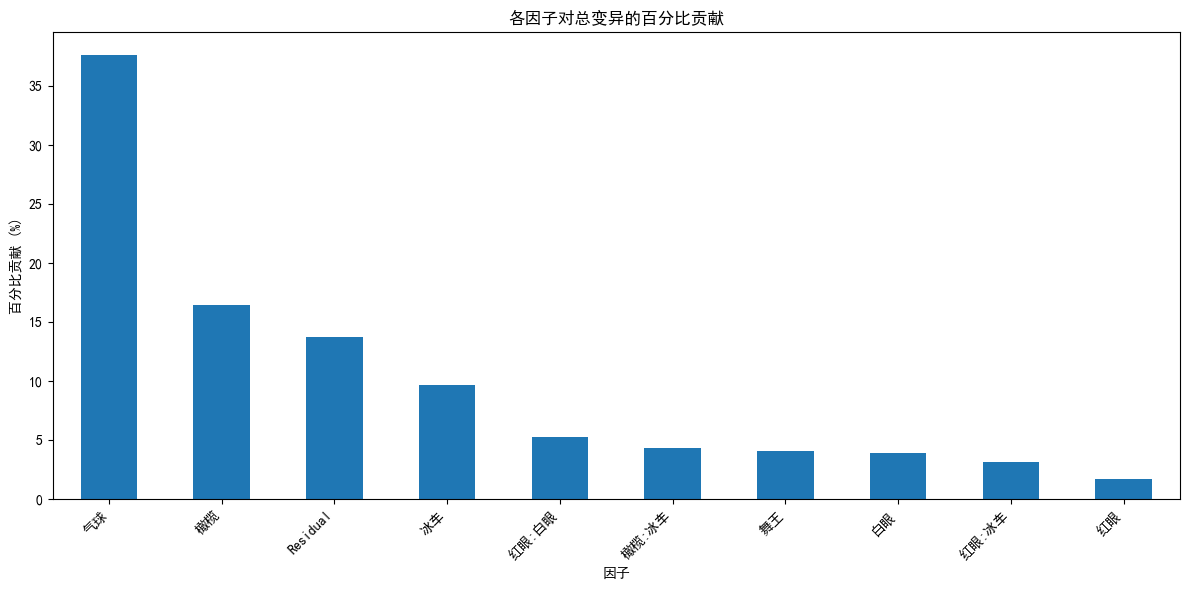

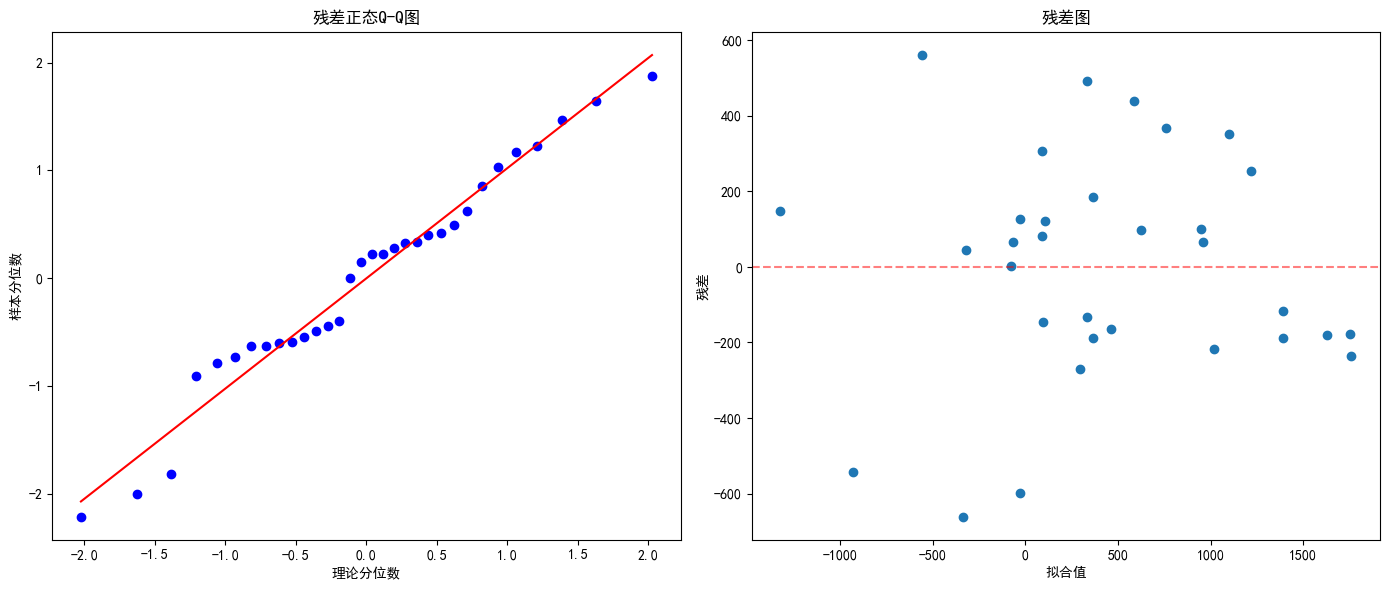

'\nDep. Variable:                      Y   R-squared:                       0.899\nModel:                            OLS   Adj. R-squared:                  0.843\nMethod:                 Least Squares   F-statistic:                     16.12\nDate:                Thu, 12 Mar 2026   Prob (F-statistic):           1.31e-07\nTime:                        17:29:53   Log-Likelihood:                -222.46\nNo. Observations:                  32   AIC:                             468.9\nDf Residuals:                      20   BIC:                             486.5\nDf Model:                          11                                         \n'

In [ ]:
model = OLS_factor_DIY_model (df,[
    '红眼', 
    '橄榄',
    '冰车', 
    '气球', 
    
    '舞王', 
    '白眼', 
    # '密度',
    
    # '撑杆', 
],[

    # '红眼:舞王', 
    '红眼:白眼', 
    '橄榄:冰车', 
    '红眼:冰车', 
    # '橄榄:密度',
    
    # '橄榄:舞王', 

    # '红眼:橄榄',
    # '红眼:密度',

    # '橄榄:白眼', 

    # '红眼:气球', 
    # '红眼:撑杆', 
    # '橄榄:气球', 
    # '橄榄:撑杆', 
])

In [57]:
pd.DataFrame(model.params)

,0
Intercept,437.5000
红眼,-103.1250
橄榄,-321.8750
冰车,-246.8750
气球,-487.5000
舞王,-160.9375
白眼,157.8125
红眼:白眼,-182.8125
橄榄:冰车,-165.6250
红眼:冰车,140.6250


In [58]:
df

,Y,路障,撑杆,铁桶,读报,铁门,橄榄,舞王,潜水,冰车,...,矿工,跳跳,蹦极,扶梯,投篮,白眼,红眼,密度,residuals,fitted
0,1025,1,-1,1,1,1,1,1,-1,-1,...,-1,1,-1,1,-1,1,1,-1,439.0625,585.9375
1,100,-1,1,1,1,-1,-1,-1,-1,1,...,-1,-1,1,1,-1,-1,-1,-1,126.5625,-26.5625
2,825,1,1,-1,1,1,1,1,-1,1,...,-1,-1,-1,-1,-1,1,-1,-1,492.1875,332.8125
3,725,1,-1,-1,1,-1,-1,1,-1,1,...,1,1,1,1,-1,-1,-1,1,98.4375,626.5625
4,1050,1,1,1,-1,-1,-1,1,-1,-1,...,1,1,-1,1,-1,-1,1,1,101.5625,948.4375
5,300,1,-1,-1,-1,-1,1,1,-1,-1,...,1,1,1,-1,-1,1,-1,1,-164.0625,464.0625
6,1475,1,1,1,1,1,-1,-1,-1,-1,...,-1,-1,1,-1,-1,1,1,-1,254.6875,1220.3125
7,-50,1,1,1,-1,1,-1,1,-1,-1,...,1,1,1,-1,1,-1,-1,-1,-145.3125,95.3125
8,200,1,1,-1,1,-1,-1,1,-1,1,...,1,1,-1,-1,1,1,-1,-1,-132.8125,332.8125
9,400,1,-1,1,-1,-1,-1,1,-1,1,...,1,-1,1,-1,1,-1,1,-1,307.8125,92.1875


In [59]:
model.predict(df).to_csv('2.1output.csv')

In [60]:
 (df,[
    '红眼', 
    '气球', 
    '橄榄',
    '投篮',
    '撑杆', 
    '舞王', 
    '白眼', 
],[
    '红眼:橄榄',
    
    '红眼:气球',
    '红眼:投篮',
    '红眼:撑杆',
    '红眼:舞王',
    '红眼:白眼',
    '红眼:密度',
    
    '橄榄:气球',
    '橄榄:投篮',
    '橄榄:撑杆',
    '橄榄:舞王',
    '橄榄:白眼',
    '橄榄:密度',
])

(       Y  路障  撑杆  铁桶  读报  铁门  橄榄  舞王  潜水  冰车  ...  矿工  跳跳  蹦极  扶梯  投篮  白眼  红眼  \
 0   1025   1  -1   1   1   1   1   1  -1  -1  ...  -1   1  -1   1  -1   1   1   
 1    100  -1   1   1   1  -1  -1  -1  -1   1  ...  -1  -1   1   1  -1  -1  -1   
 2    825   1   1  -1   1   1   1   1  -1   1  ...  -1  -1  -1  -1  -1   1  -1   
 3    725   1  -1  -1   1  -1  -1   1  -1   1  ...   1   1   1   1  -1  -1  -1   
 4   1050   1   1   1  -1  -1  -1   1  -1  -1  ...   1   1  -1   1  -1  -1   1   
 5    300   1  -1  -1  -1  -1   1   1  -1  -1  ...   1   1   1  -1  -1   1  -1   
 6   1475   1   1   1   1   1  -1  -1  -1  -1  ...  -1  -1   1  -1  -1   1   1   
 7    -50   1   1   1  -1   1  -1   1  -1  -1  ...   1   1   1  -1   1  -1  -1   
 8    200   1   1  -1   1  -1  -1   1  -1   1  ...   1   1  -1  -1   1   1  -1   
 9    400   1  -1   1  -1  -1  -1   1  -1   1  ...   1  -1   1  -1   1  -1   1   
 10  1450   1   1  -1   1  -1  -1  -1  -1  -1  ...   1  -1   1   1  -1   1  -1   
 11     0   1   